In [1]:
import pandas as pd

# Load in data
training_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")


# Describe data
print(training_df.describe())
print(training_df.head())
print(training_df.shape)

       Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
count           84998.000000      100000.000000     100000.00000   
mean             4194.170850          17.091280         22.47443   
std              3183.686167         117.404834        129.05741   
min               303.645417          -1.000000          0.00000   
25%              1625.568229           3.000000          4.00000   
50%              3093.745000           6.000000          5.00000   
75%              5957.448333           7.000000          7.00000   
max             15204.633333        1798.000000       1499.00000   

       Interest_Rate  Delay_from_due_date  Num_Credit_Inquiries  \
count  100000.000000        100000.000000          98035.000000   
mean       72.466040            21.068780             27.754251   
std       466.422621            14.860104            193.177339   
min         1.000000            -5.000000              0.000000   
25%         8.000000            10.000000           

/var/folders/g7/plj0qbkx797d4qbxp819jprh0000gn/T/ipykernel_45561/3319456046.py:4: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  training_df = pd.read_csv("./data/train.csv")


In [2]:
# Preprocessing

# Drop useless columns
training_df = training_df.drop(columns=["ID", "Customer_ID", "Month", "Name", "SSN", "Age", "Occupation", "Type_of_Loan", "Credit_History_Age", "Payment_Behaviour"])

training_df.columns.tolist()

['Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Credit_Score']

In [3]:
training_df.dtypes

Annual_Income                   str
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                     str
Delay_from_due_date           int64
Num_of_Delayed_Payment          str
Changed_Credit_Limit            str
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt                str
Credit_Utilization_Ratio    float64
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly         str
Monthly_Balance              object
Credit_Score                    str
dtype: object

In [4]:
# List of columns that should be numeric but have underscores/dirty strings
dirty_numeric_cols = ["Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]

for col in dirty_numeric_cols:
    # Remove underscores
    training_df[col] = training_df[col].astype(str).str.replace('_', '', regex=False)
    
    # Convert to numeric
    training_df[col] = pd.to_numeric(training_df[col], errors='coerce')
    
    # Fill NaNs with the median of this specific column
    col_median = training_df[col].median()
    training_df[col] = training_df[col].fillna(col_median)

# Check the results
print(training_df.dtypes)
print("\nMissing values remaining:", training_df[dirty_numeric_cols].isnull().sum().sum())

Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
Credit_Score                    str
dtype: object

Missing values remaining: 0


In [5]:
# Replace the underscores with Unknown
training_df['Credit_Mix'] = training_df['Credit_Mix'].replace('_', 'Unknown')

In [6]:
# List of categorical features to encode
categorical_features = ["Credit_Mix", "Payment_of_Min_Amount"]

# Apply One-Hot Encoding
training_df = pd.get_dummies(training_df, columns=categorical_features, drop_first=True)

In [7]:
print(training_df['Credit_Score'].unique())

<StringArray>
['Good', 'Standard', 'Poor']
Length: 3, dtype: str


In [8]:
# Map the target variable to integers
score_mapping = {
    "Poor": 0,
    "Standard": 1,
    "Good": 2
}

training_df['Credit_Score'] = training_df['Credit_Score'].map(score_mapping)

In [9]:
print(f"New DataFrame shape: {training_df.shape}")
print("\nNew columns created:")
print([col for col in training_df.columns if "Credit_Mix" in col or "Payment" in col])
print("\nTarget Variable Sample:")
print(training_df['Credit_Score'].unique())

New DataFrame shape: (100000, 21)

New columns created:
['Num_of_Delayed_Payment', 'Credit_Mix_Good', 'Credit_Mix_Standard', 'Credit_Mix_Unknown', 'Payment_of_Min_Amount_No', 'Payment_of_Min_Amount_Yes']

Target Variable Sample:
[2 1 0]


In [10]:
training_df.columns.tolist()

['Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Credit_Score',
 'Credit_Mix_Good',
 'Credit_Mix_Standard',
 'Credit_Mix_Unknown',
 'Payment_of_Min_Amount_No',
 'Payment_of_Min_Amount_Yes']

In [11]:
training_df.dtypes

Annual_Income                float64
Monthly_Inhand_Salary        float64
Num_Bank_Accounts              int64
Num_Credit_Card                int64
Interest_Rate                  int64
Num_of_Loan                    int64
Delay_from_due_date            int64
Num_of_Delayed_Payment       float64
Changed_Credit_Limit         float64
Num_Credit_Inquiries         float64
Outstanding_Debt             float64
Credit_Utilization_Ratio     float64
Total_EMI_per_month          float64
Amount_invested_monthly      float64
Monthly_Balance              float64
Credit_Score                   int64
Credit_Mix_Good                 bool
Credit_Mix_Standard             bool
Credit_Mix_Unknown              bool
Payment_of_Min_Amount_No        bool
Payment_of_Min_Amount_Yes       bool
dtype: object

In [12]:
# Training and test splits and model selection
from sklearn.model_selection import train_test_split

X = training_df.drop(columns=["Credit_Score"])
X = X.fillna(X.median())

y = training_df["Credit_Score"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(X_train_scaled, y_train)

SVM_model = SVC(random_state=42)
SVM_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
# Evaluate models
from sklearn.metrics import accuracy_score, f1_score

# Get predicted scores from X_test
predicted_scores_logistic = logistic_model.predict(X_test_scaled)
predicted_scores_DT = decision_tree_model.predict(X_test_scaled)
predicted_scores_forest = forest_model.predict(X_test_scaled)
predicted_scores_SVM = SVM_model.predict(X_test_scaled)

# Get accuracy
accuracy_logistic = accuracy_score(y_test, predicted_scores_logistic)
accuracy_DT = accuracy_score(y_test, predicted_scores_DT)
accuracy_forest = accuracy_score(y_test, predicted_scores_forest)
accuracy_SVM = accuracy_score(y_test, predicted_scores_SVM)

# Get F1 Score
f1_score_logistic = f1_score(y_test, predicted_scores_logistic, average='weighted')
f1_score_DT = f1_score(y_test, predicted_scores_DT, average='weighted')
f1_score_forest = f1_score(y_test, predicted_scores_forest, average='weighted')
f1_score_SVM = f1_score(y_test, predicted_scores_SVM, average='weighted')

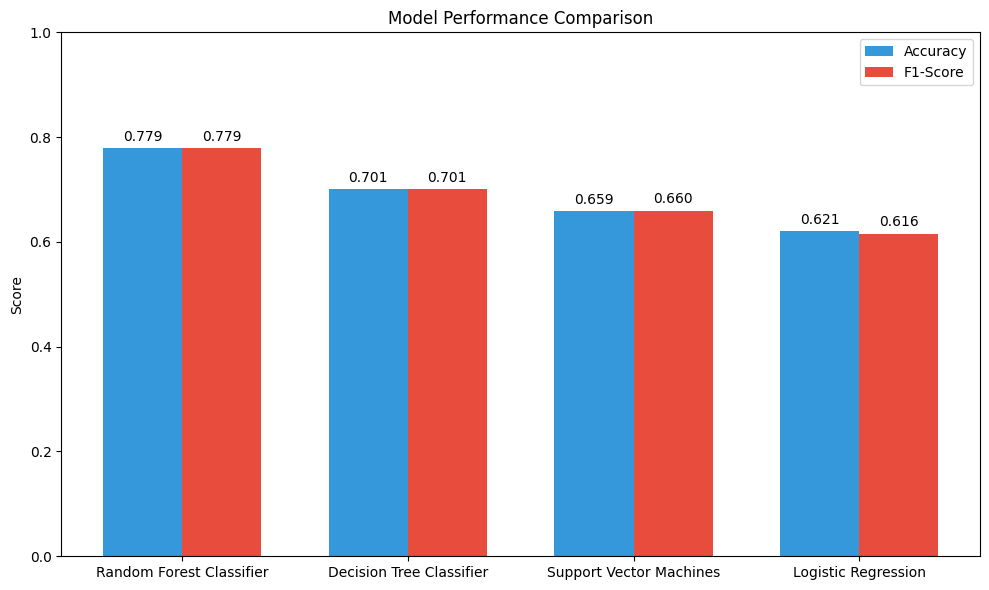

In [23]:
import matplotlib.pyplot as plt
import numpy as np

scores = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_logistic,
        "F1-Score": f1_score_logistic
    },
    {
        "Model": "Decision Tree Classifier",
        "Accuracy": accuracy_DT,
        "F1-Score": f1_score_DT
    },
    {
        "Model": "Random Forest Classifier",
        "Accuracy": accuracy_forest,
        "F1-Score": f1_score_forest
    },
    {
        "Model": "Support Vector Machines",
        "Accuracy": accuracy_SVM,
        "F1-Score": f1_score_SVM
    }
]

scores_df = pd.DataFrame(scores)
scores_df = scores_df.sort_values(by="Accuracy", ascending=False)

x = np.arange(len(scores_df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, scores_df['Accuracy'], width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, scores_df['F1-Score'], width, label='F1-Score', color='#e74c3c')

# Add labels and formatting
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(scores_df['Model'])
ax.set_ylim(0, 1.0) # Set limit to 100% for perspective
ax.legend()

# Function to add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('model_comparison.png')